# KC House Price Prediction

Predict home prices in **King County, Washington** using machine learning.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures


In [2]:
df = pd.read_csv('kc_house_data.csv')


## 1. Data Loading & Inspection

In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  str    
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   floors         21613 non-null  float64
 7   waterfront     21613 non-null  int64  
 8   view           21613 non-null  int64  
 9   condition      21613 non-null  int64  
 10  grade          21613 non-null  int64  
 11  yr_built       21613 non-null  int64  
 12  yr_renovated   21613 non-null  int64  
 13  zipcode        21613 non-null  int64  
 14  lat            21613 non-null  float64
 15  long           21613 non-null  float64
 16  sqft_living15  21613 non-null  int64  
 17  sqft_lot15     21613 non-null  int64  
 18  sqft_lot       21

In [4]:
df.describe()


,id,price,bedrooms,bathrooms,sqft_living,floors,waterfront,view,condition,grade,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,sqft_lot,sqft_above,sqft_basement
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000
mean,4.580302e+09,5.401822e+05,3.370842,2.114757,2079.899736,1.494309,0.007542,0.234303,3.409430,7.656873,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652,1.510697e+04,1788.390691,291.509045
std,2.876566e+09,3.673622e+05,0.930062,0.770163,918.440897,0.539989,0.086517,0.766318,0.650743,1.175459,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631,4.142051e+04,828.090978,442.575043
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000,5.200000e+02,290.000000,0.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,1.000000,0.000000,0.000000,3.000000,7.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000,5.040000e+03,1190.000000,0.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,1.500000,0.000000,0.000000,3.000000,7.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000,7.618000e+03,1560.000000,0.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,2.000000,0.000000,0.000000,4.000000,8.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000,1.068800e+04,2210.000000,560.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,3.500000,1.000000,4.000000,5.000000,13.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000,1.651359e+06,9410.000000,4820.000000


In [5]:
df.duplicated().sum()


np.int64(0)

In [6]:
df.isna().sum()


id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
floors           0
waterfront       0
view             0
condition        0
grade            0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
sqft_lot         0
sqft_above       0
sqft_basement    0
dtype: int64

In [7]:
numcol = ["price","bedrooms","bathrooms","sqft_living","sqft_lot",
          "sqft_above","sqft_basement","sqft_living15","sqft_lot15",
          "lat","long"]

catcol = ["zipcode","condition","grade","waterfront","view","floors",
          "yr_built","yr_renovated"]


In [8]:
df['date'] = pd.to_datetime(df['date'])
df['date']


0       2014-10-13
1       2014-12-09
2       2015-02-25
3       2014-12-09
4       2015-02-18
           ...    
21608   2014-05-21
21609   2015-02-23
21610   2014-06-23
21611   2015-01-16
21612   2014-10-15
Name: date, Length: 21613, dtype: datetime64[us]

In [9]:
df.drop('id',axis=1,inplace=True)


## 2. Exploratory Data Analysis

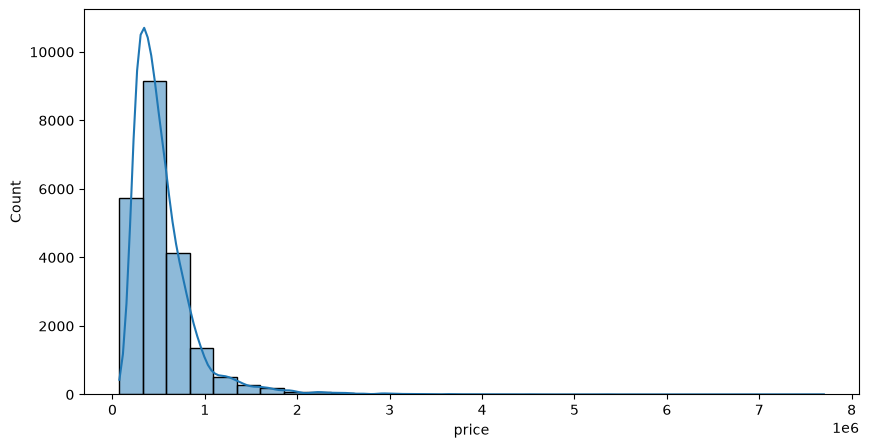

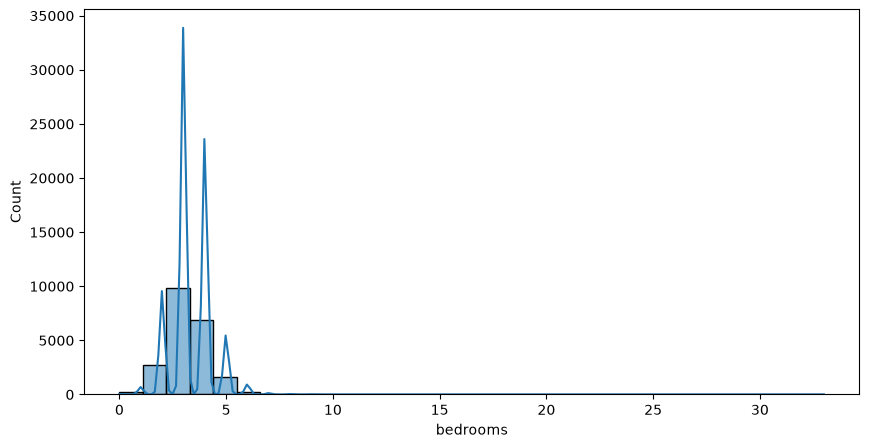

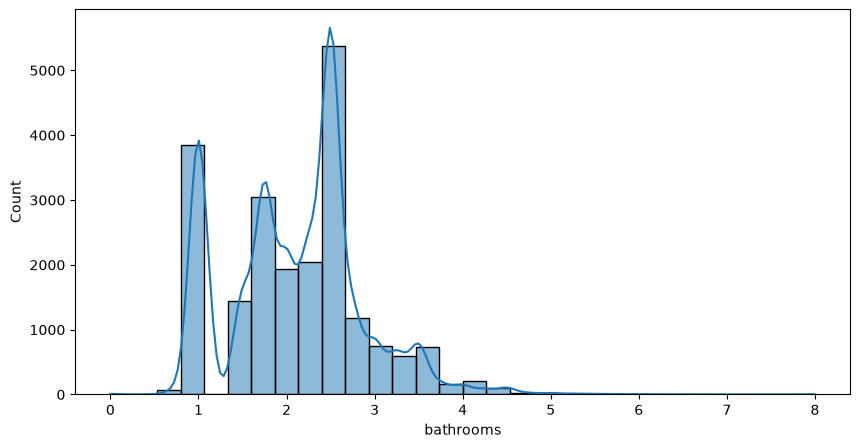

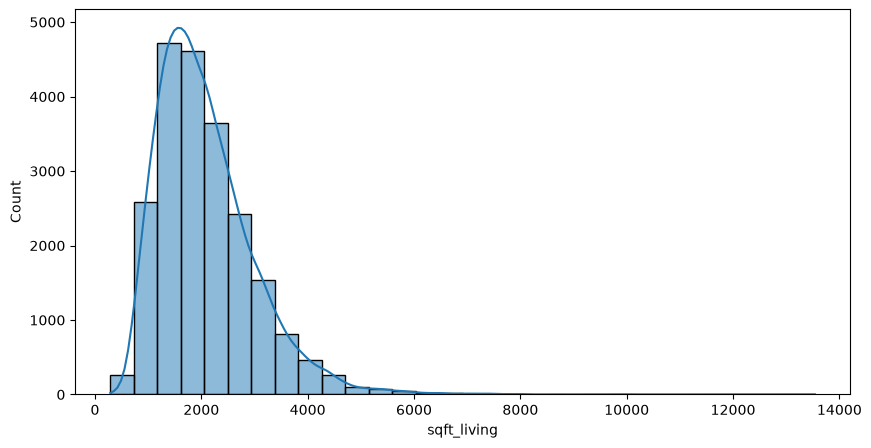

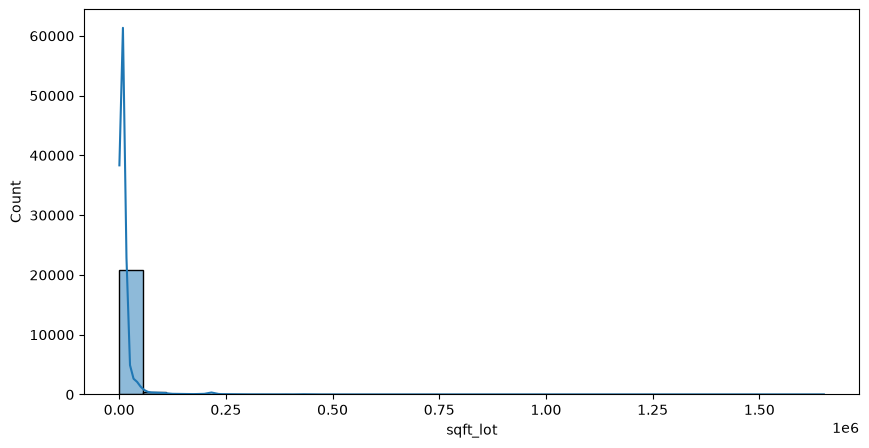

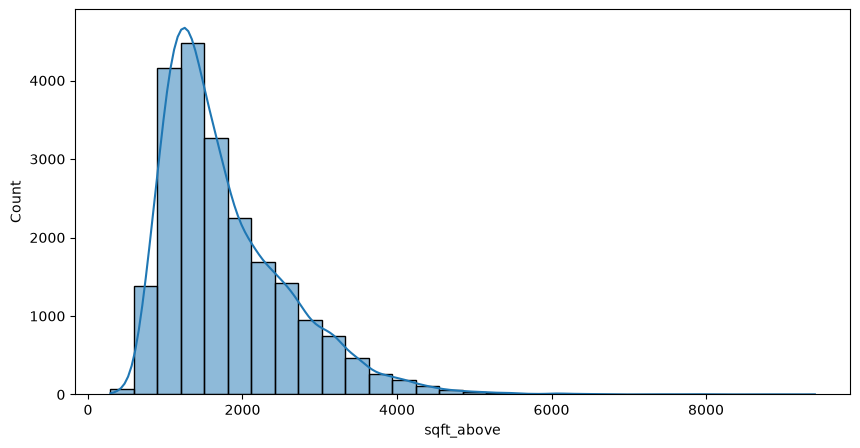

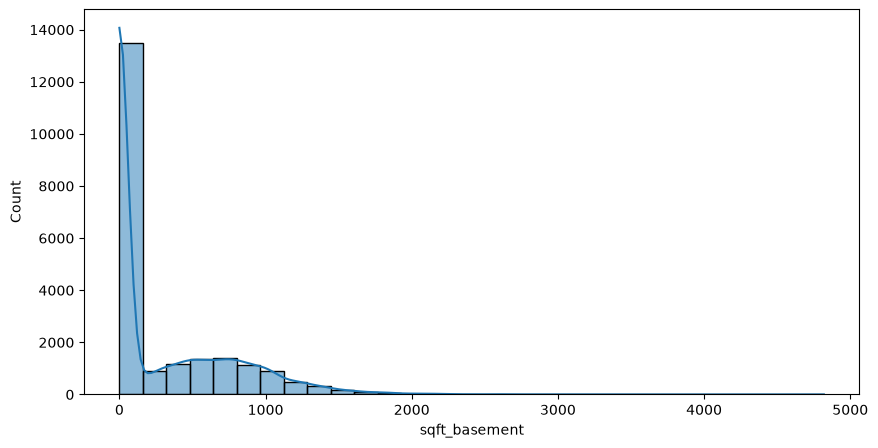

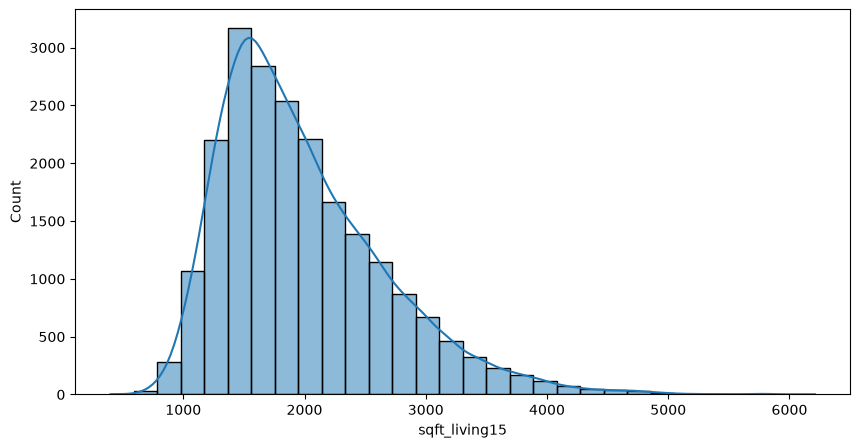

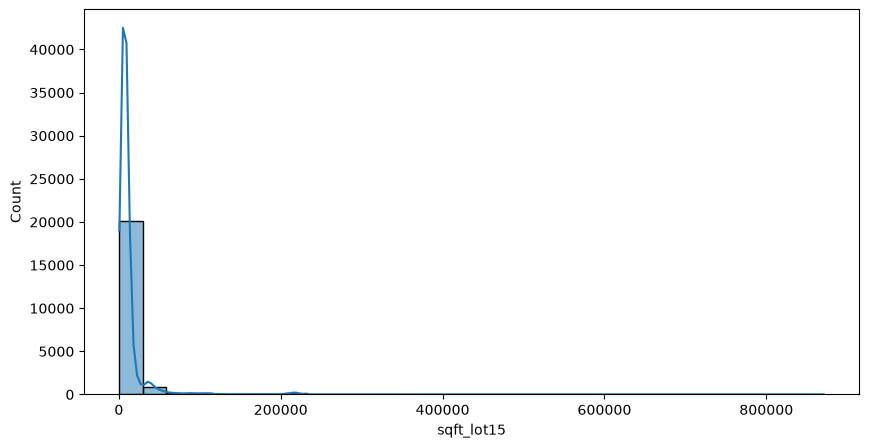

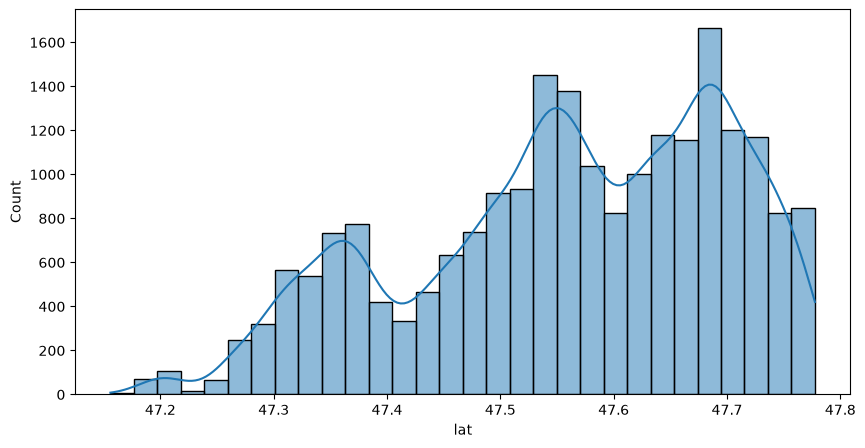

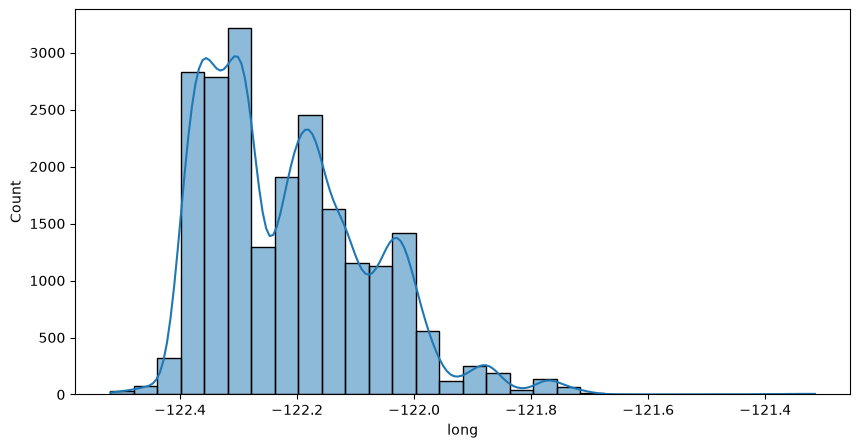

In [10]:
for col in numcol:
  plt.figure(figsize=(10,5))
  sns.histplot(df[col],bins=30,kde=True)
  plt.show()


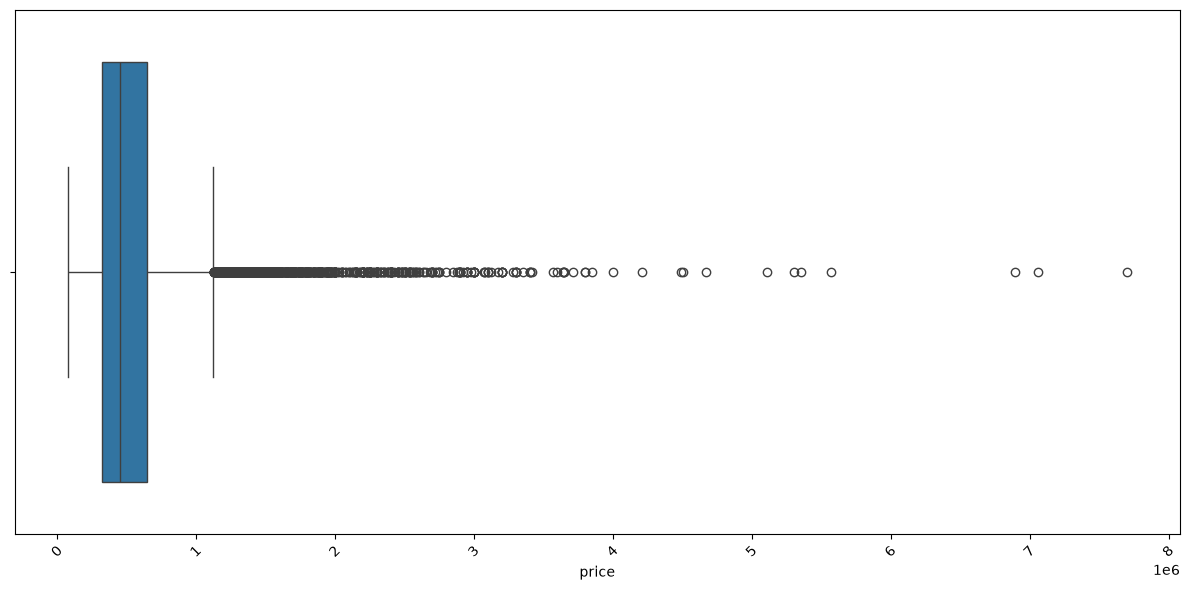

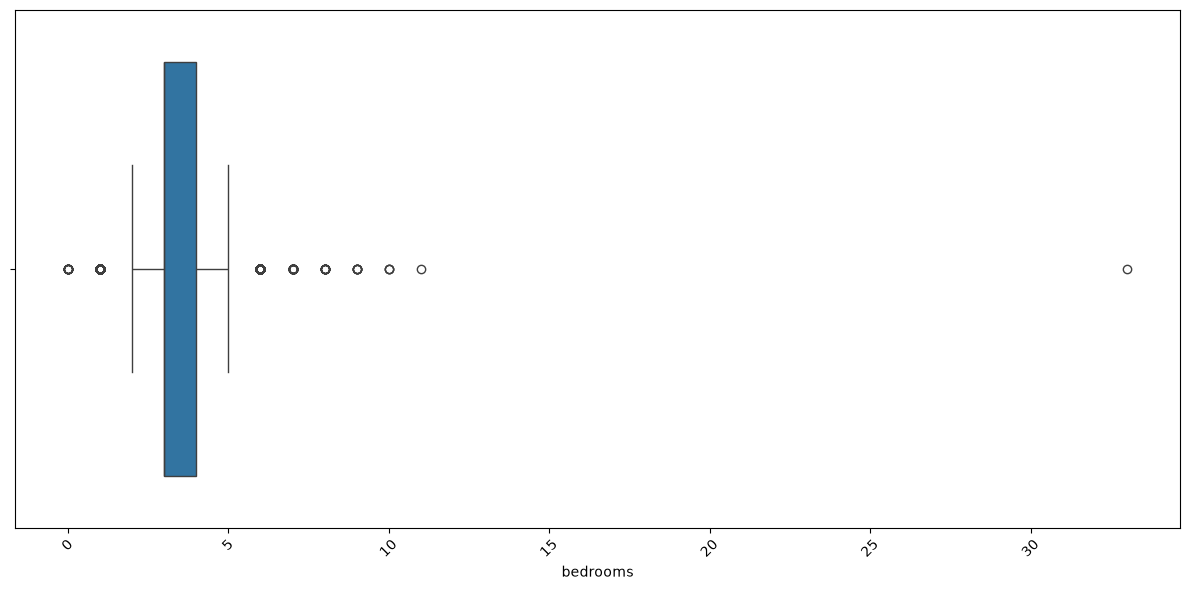

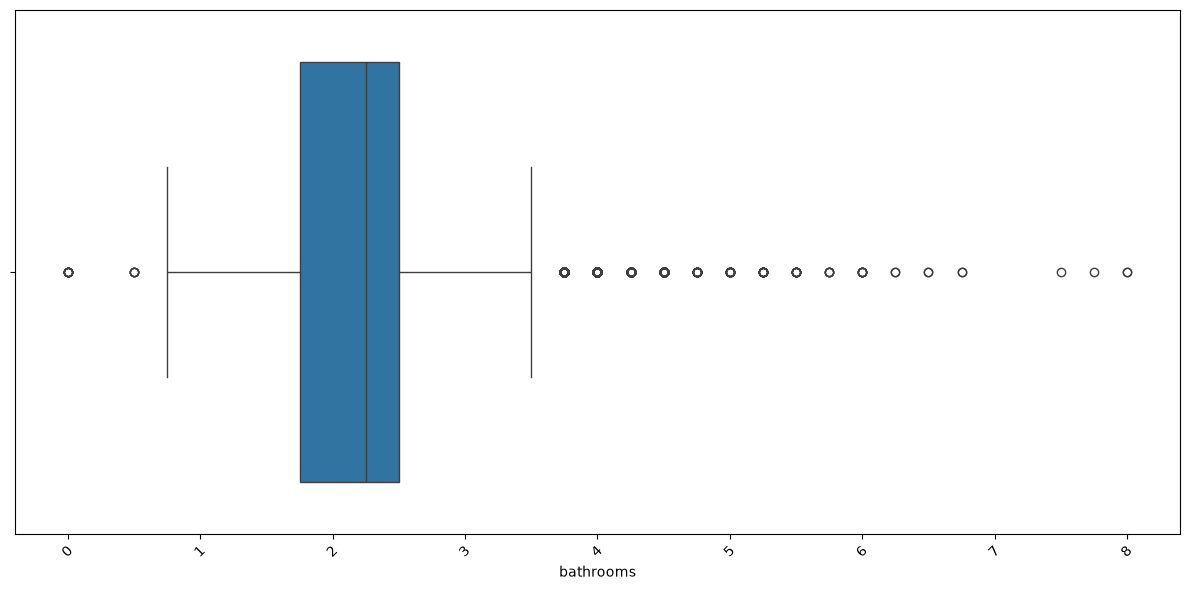

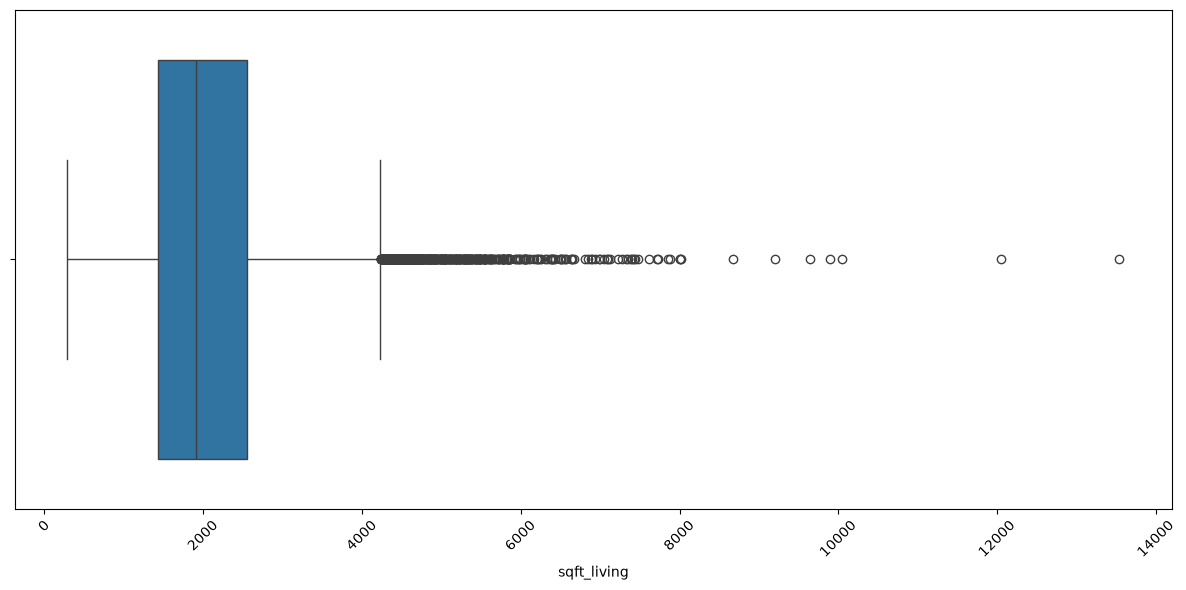

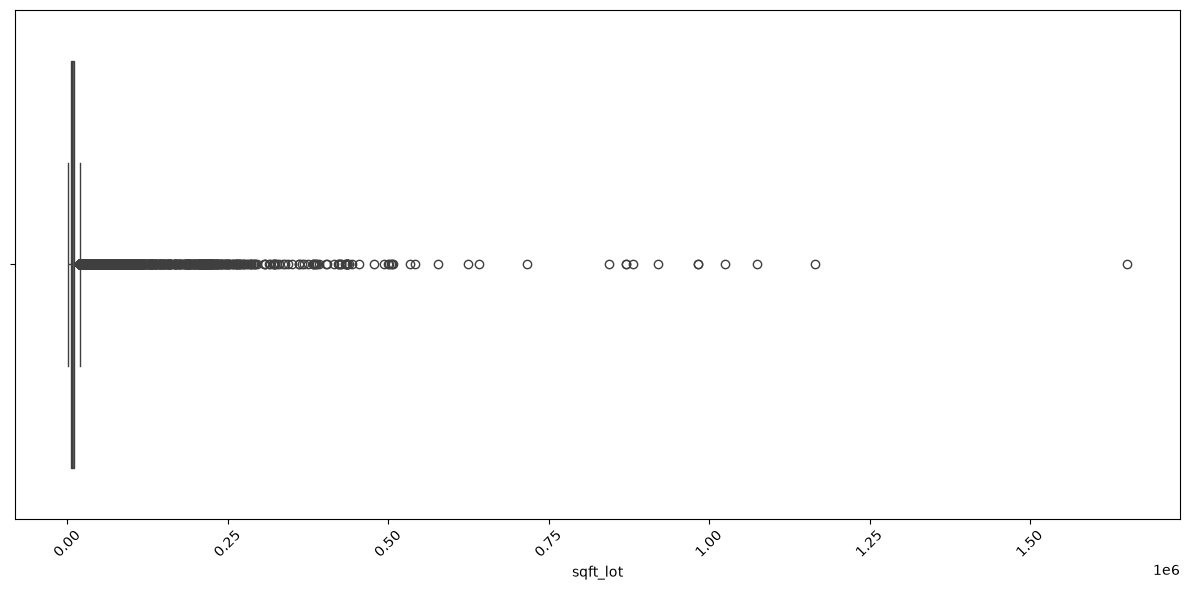

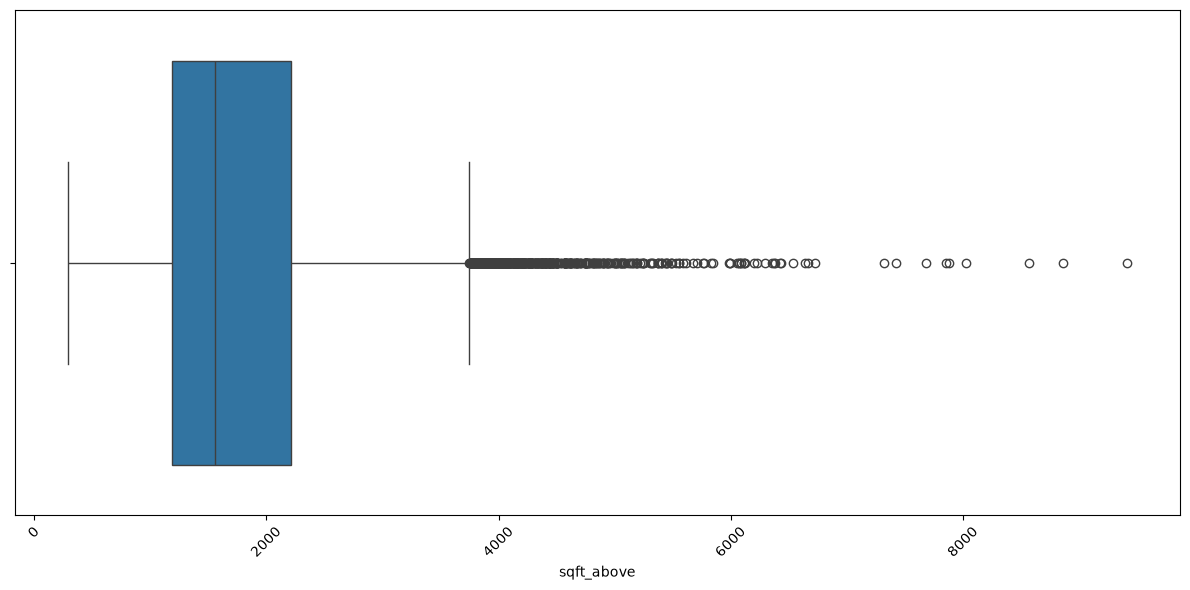

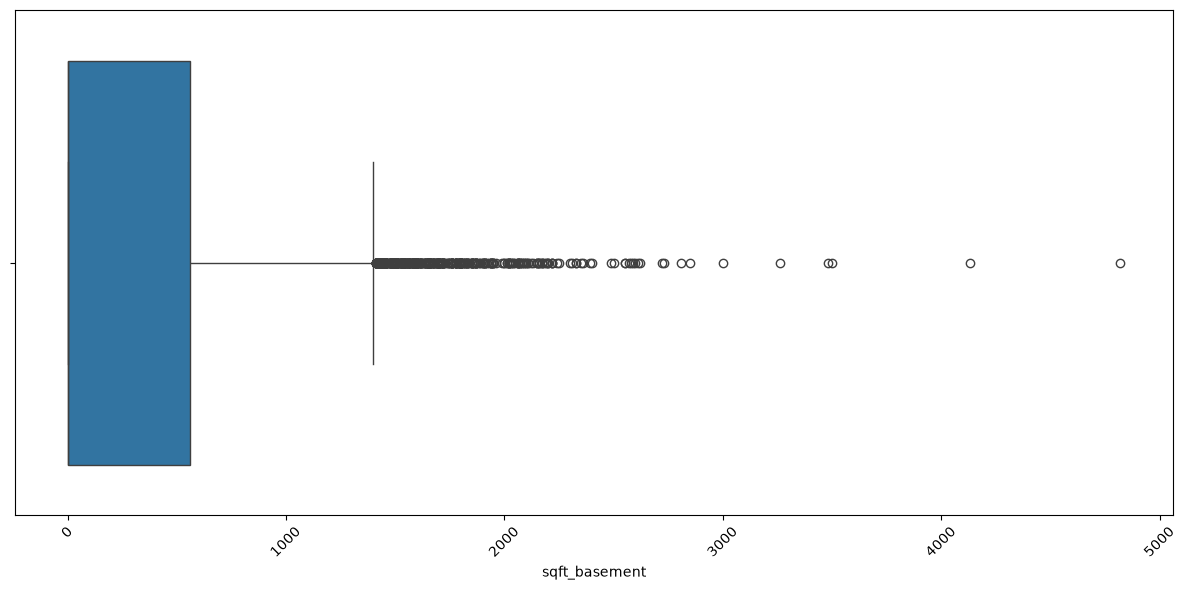

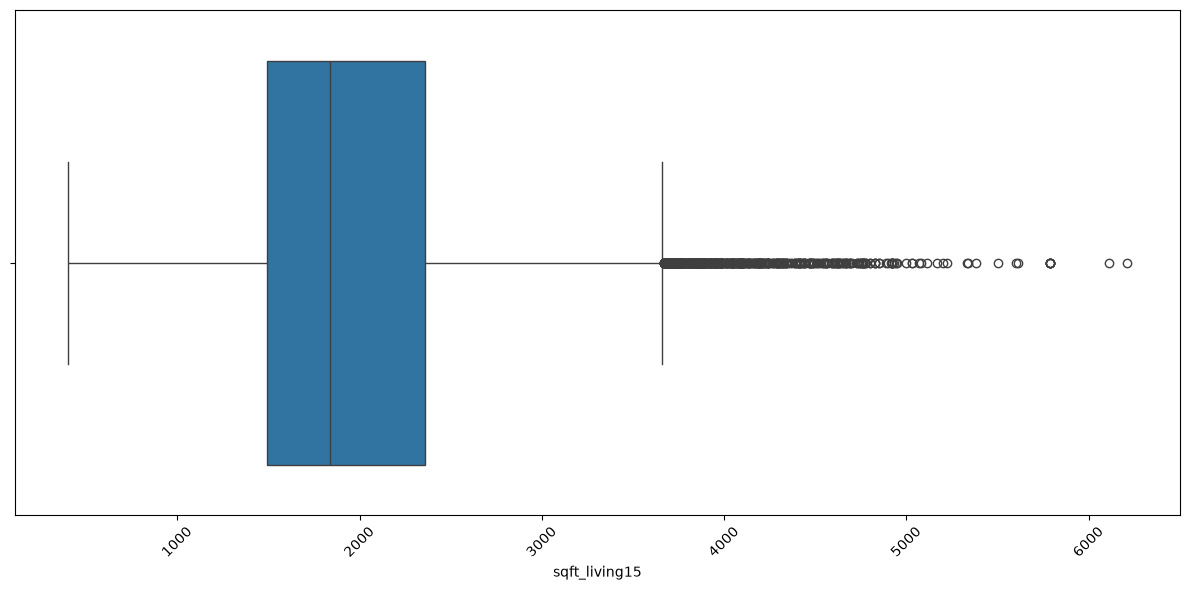

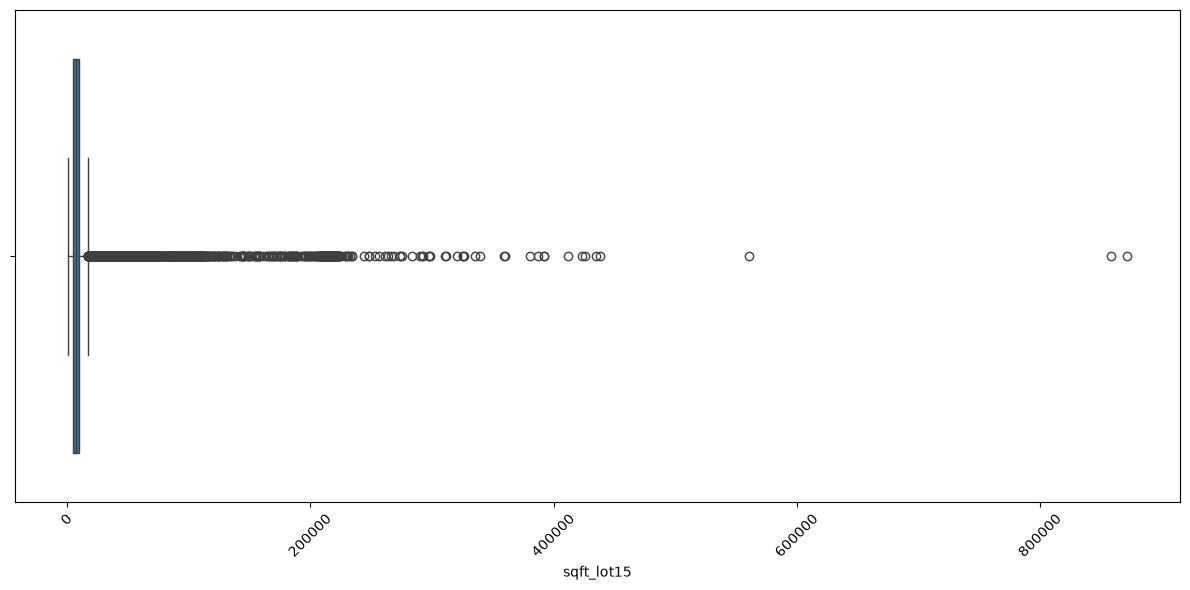

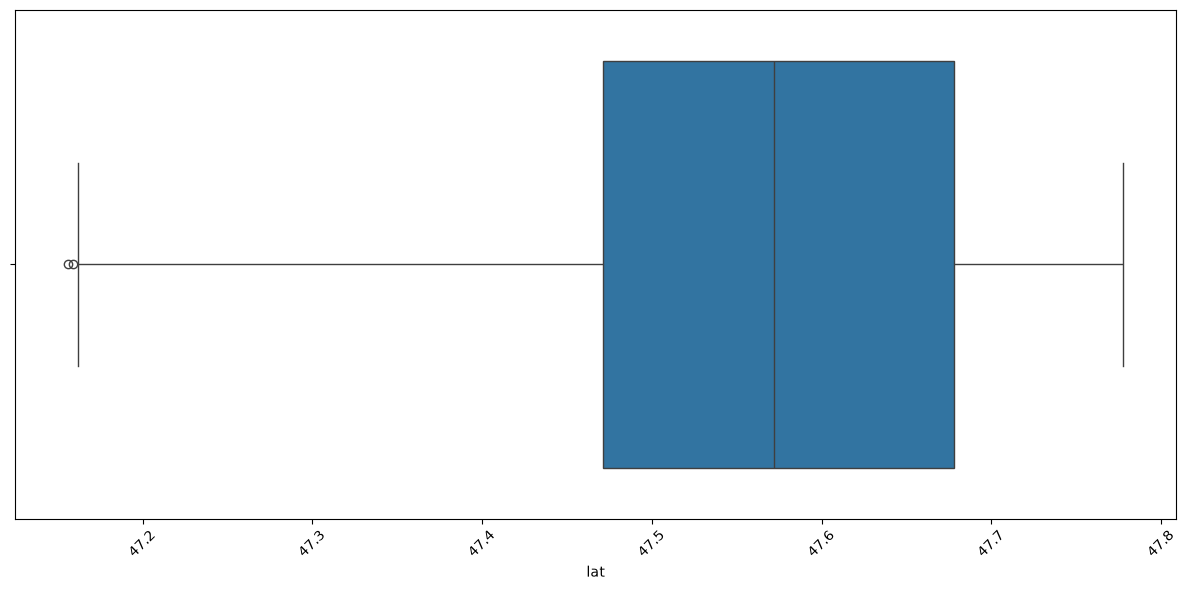

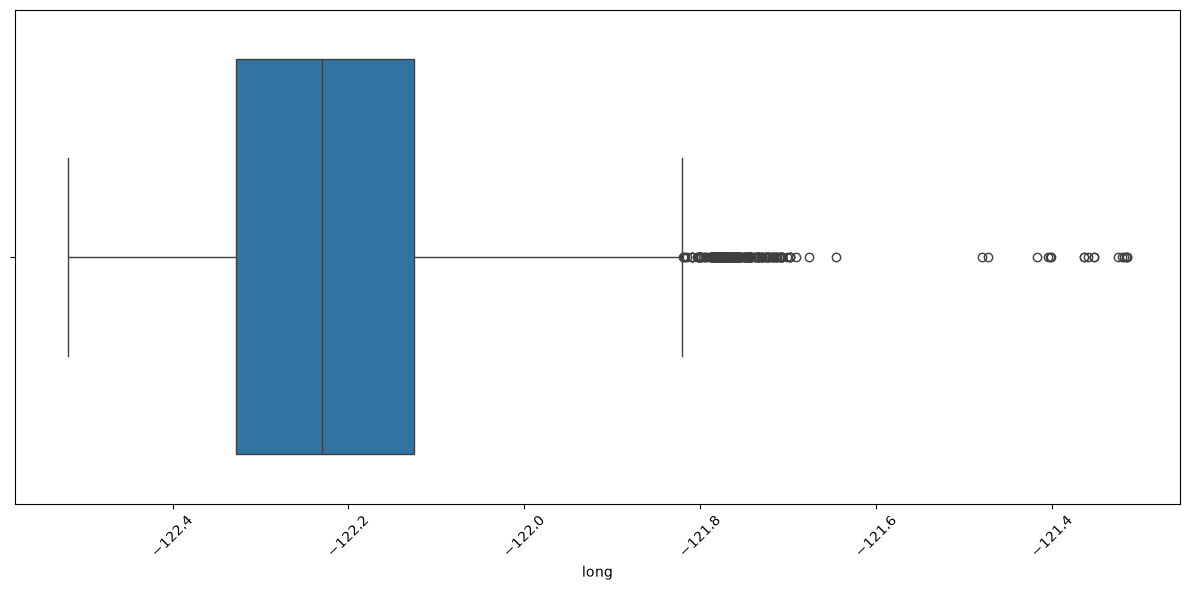

In [11]:
for col in numcol:
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df, x=col)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


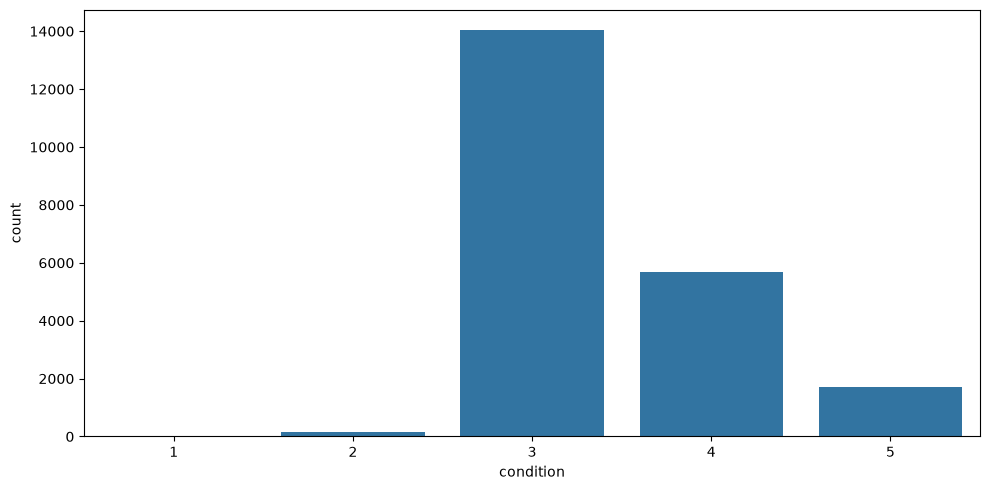

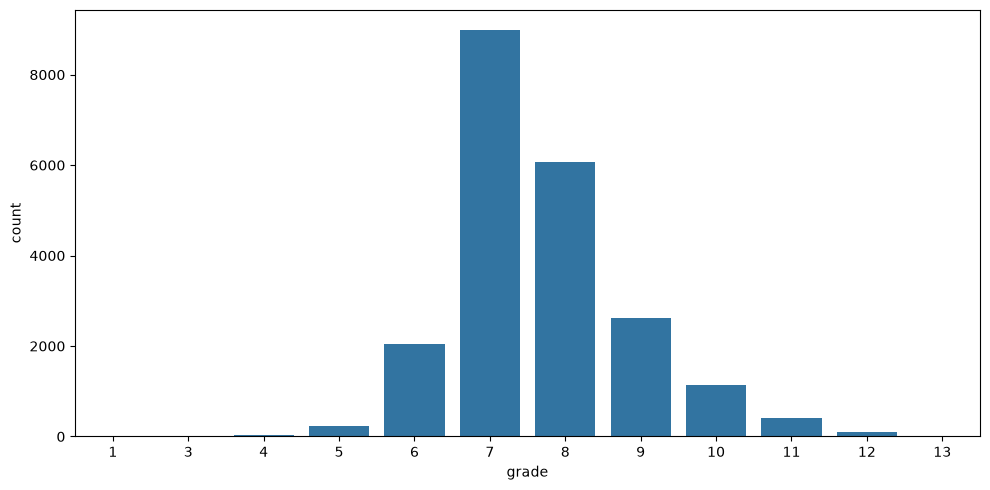

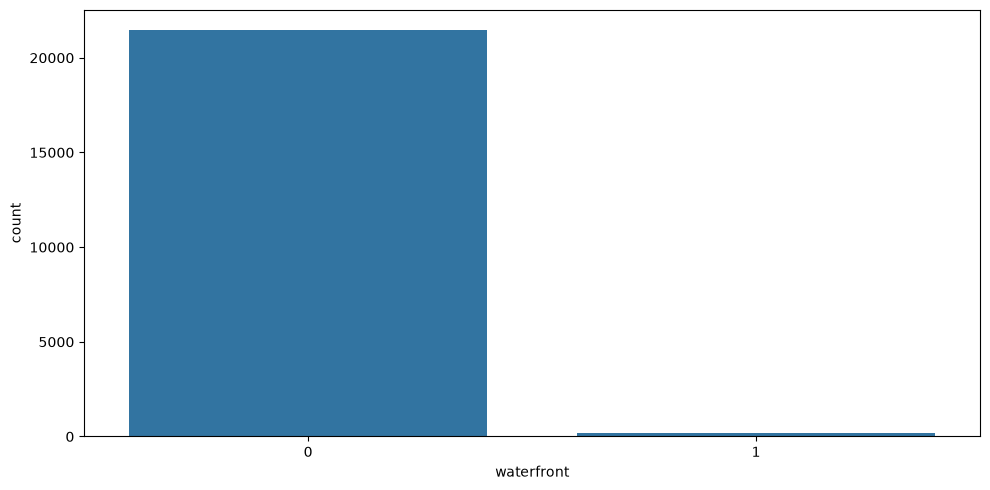

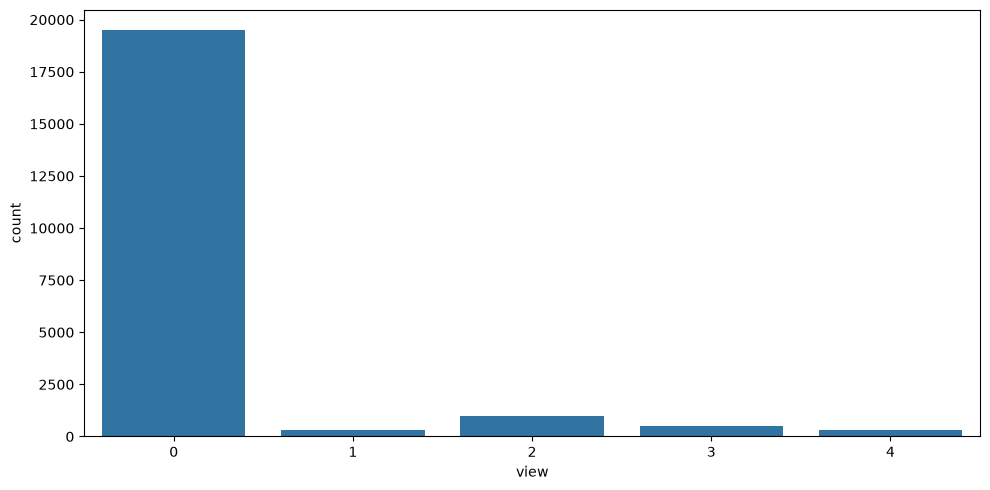

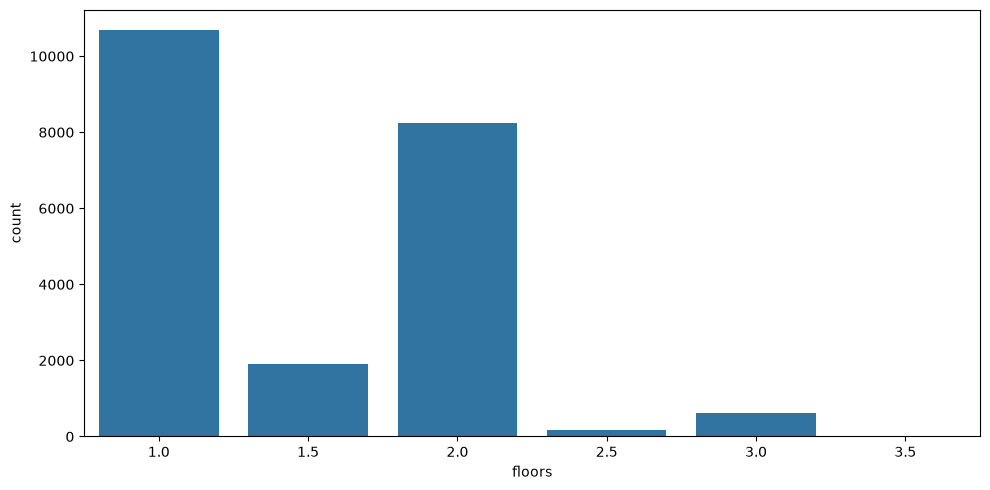

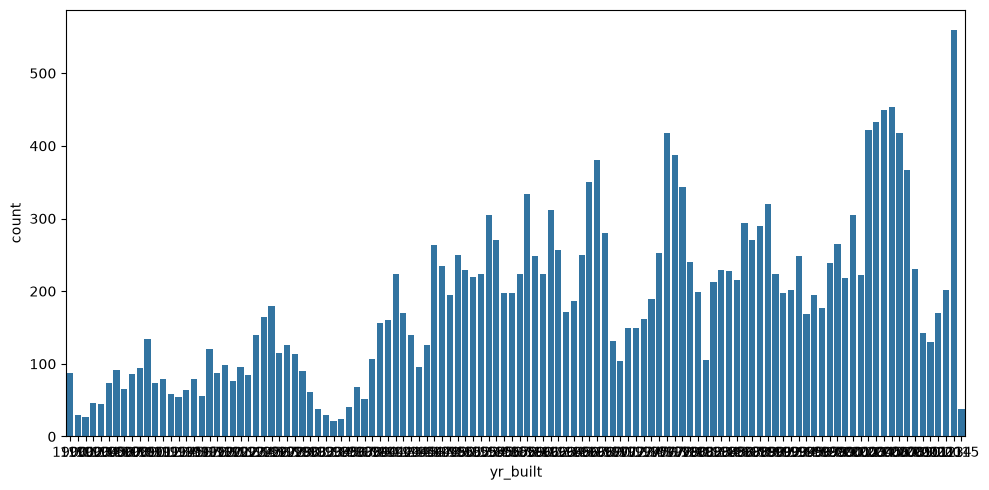

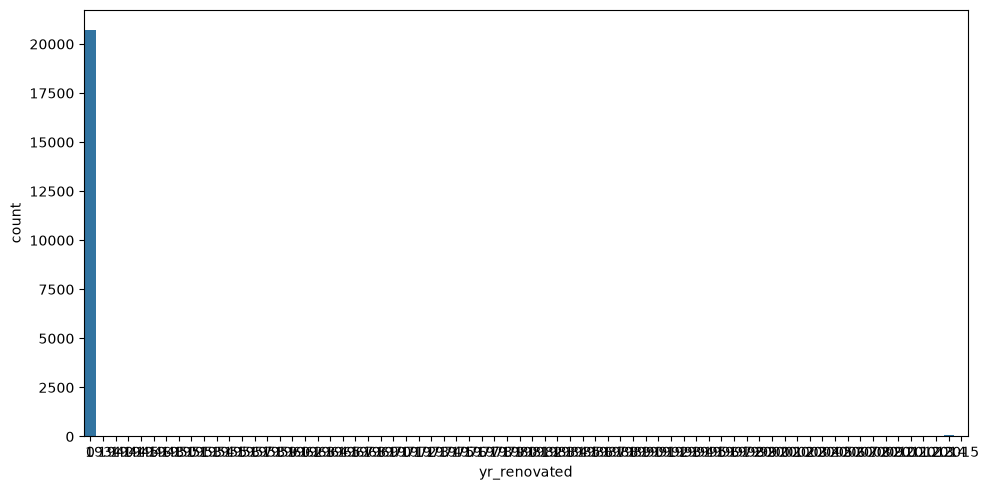

In [12]:
for col in catcol:
    if col == 'zipcode':
        continue
    plt.figure(figsize=(10,5))
    sns.countplot(data=df, x=col)
    plt.tight_layout()
    plt.show()


C:\Users\hashe\AppData\Local\Temp\ipykernel_40816\1426372491.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=median_prices.index, y=median_prices.values, palette='viridis')


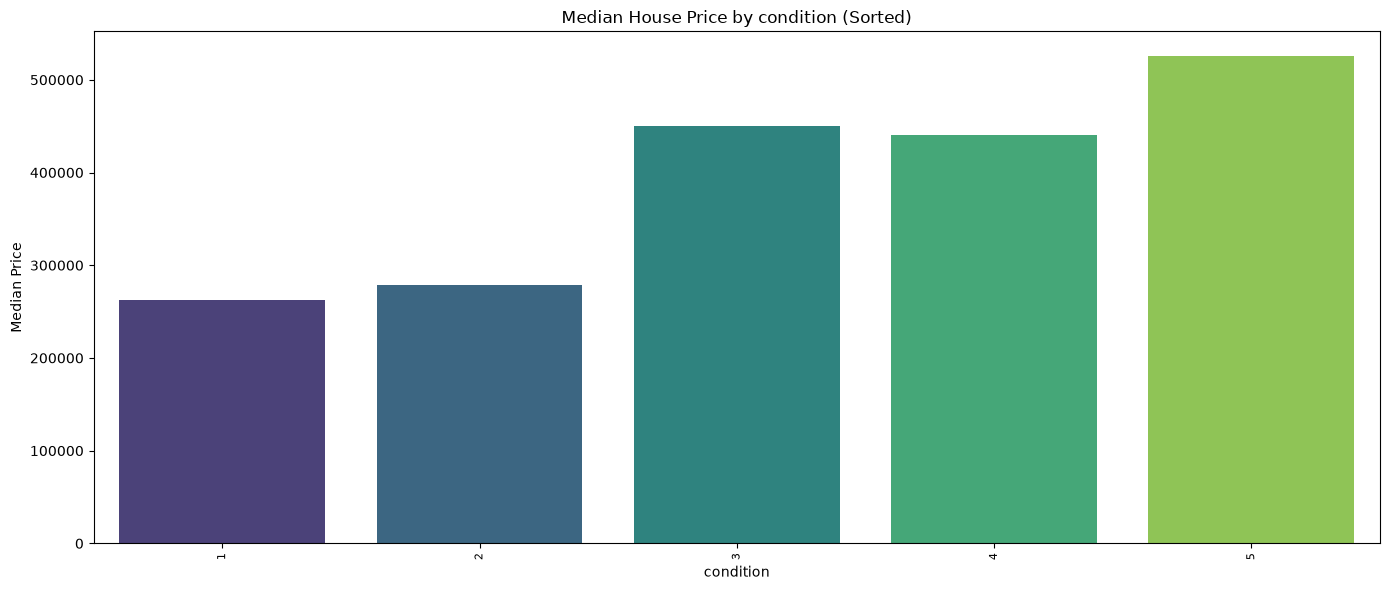

In [13]:
median_prices = df.groupby('condition')['price'].median().sort_values(ascending=False)

plt.figure(figsize=(14, 6))
sns.barplot(x=median_prices.index, y=median_prices.values, palette='viridis')
plt.xticks(rotation=90, fontsize=8)
plt.title("Median House Price by condition (Sorted)")
plt.xlabel("condition")
plt.ylabel("Median Price")
plt.tight_layout()
plt.show()


C:\Users\hashe\AppData\Local\Temp\ipykernel_40816\3543447884.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=median_prices.index, y=median_prices.values, palette='viridis')


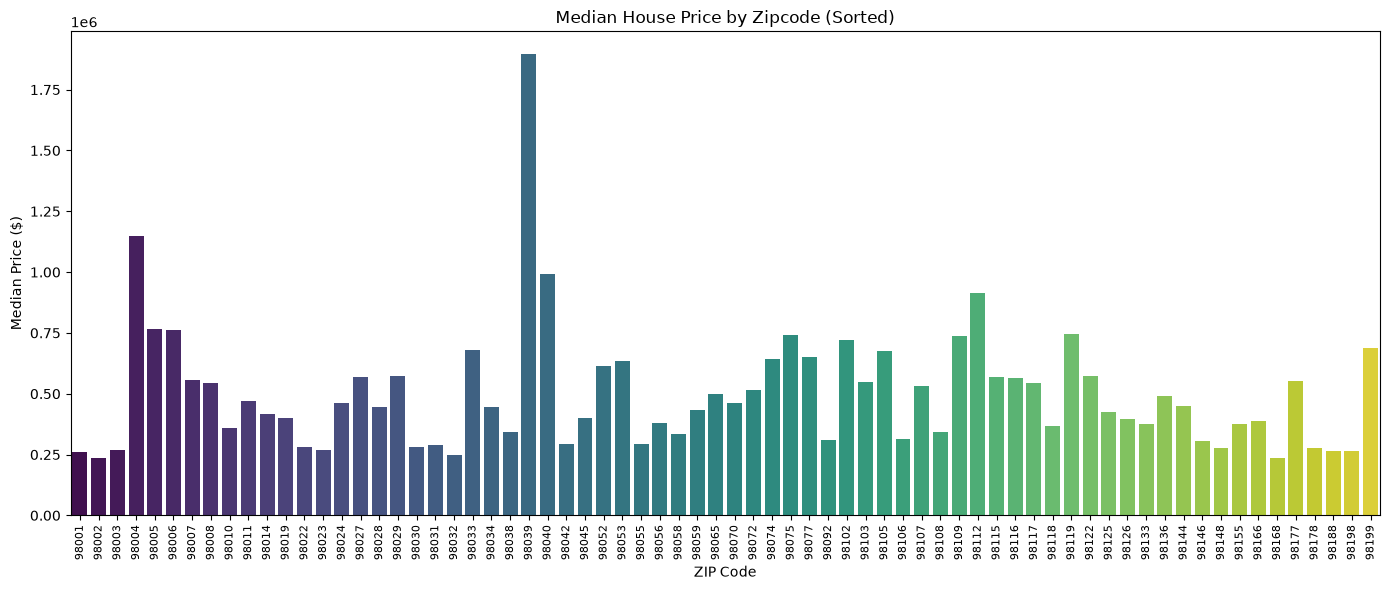

In [14]:
median_prices = df.groupby('zipcode')['price'].median().sort_values(ascending=False)

plt.figure(figsize=(14, 6))
sns.barplot(x=median_prices.index, y=median_prices.values, palette='viridis')
plt.xticks(rotation=90, fontsize=8)
plt.title("Median House Price by Zipcode (Sorted)")
plt.xlabel("ZIP Code")
plt.ylabel("Median Price ($)")
plt.tight_layout()
plt.show()


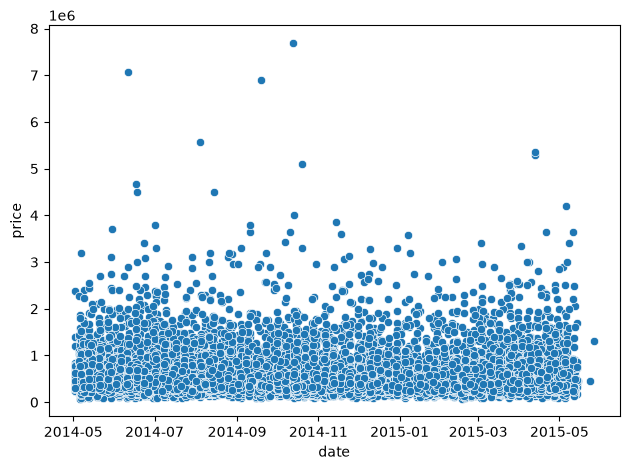

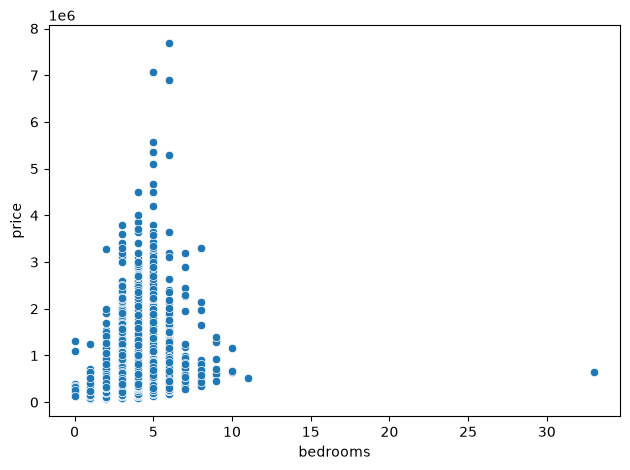

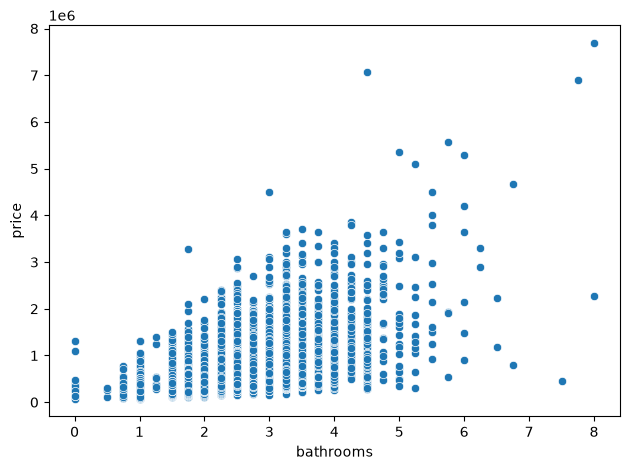

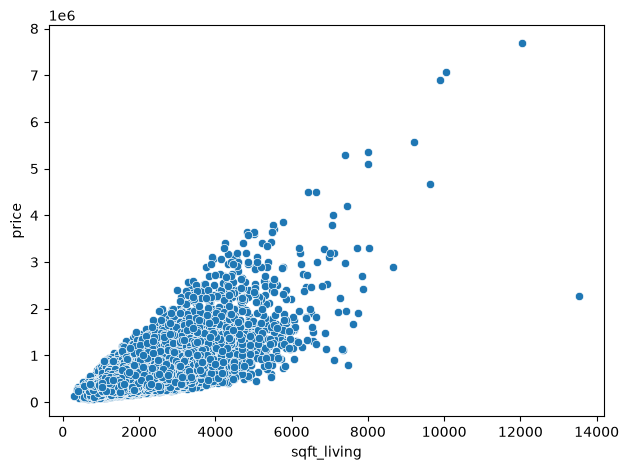

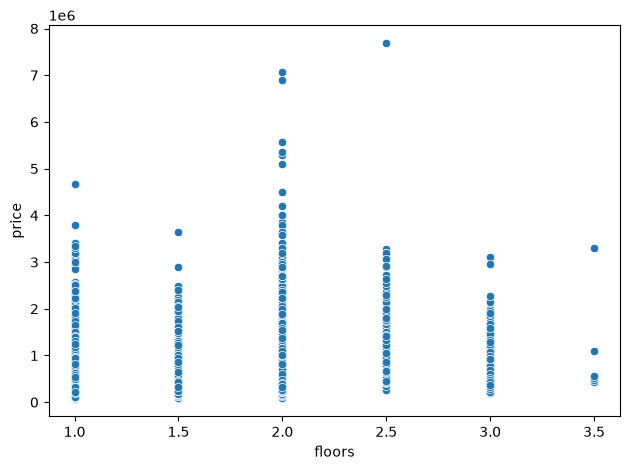

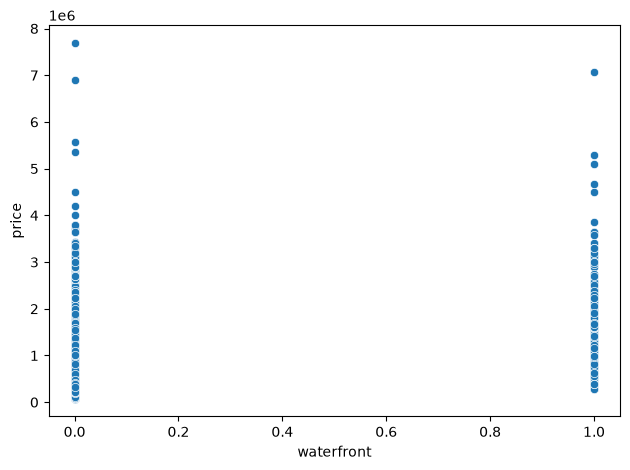

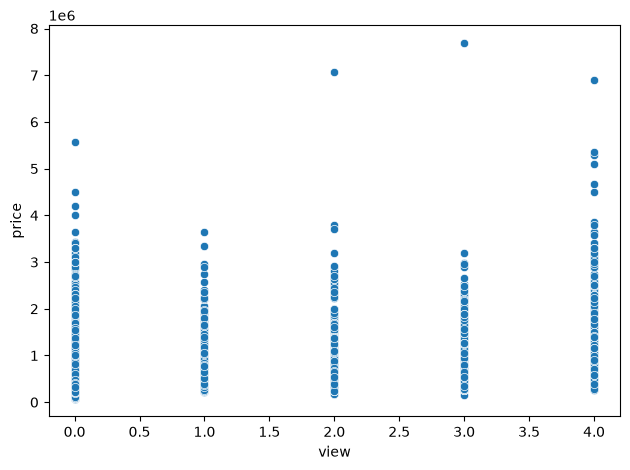

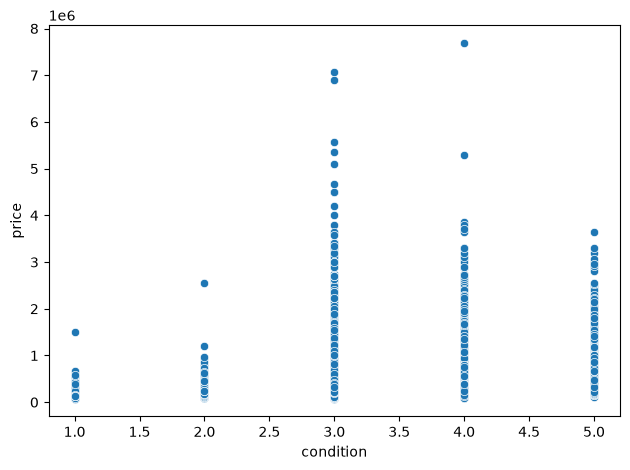

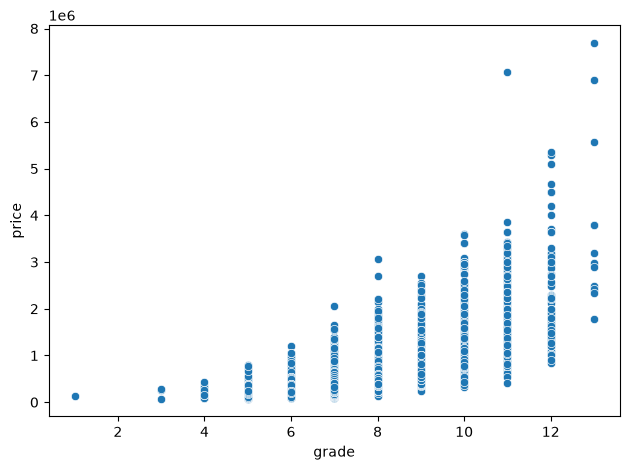

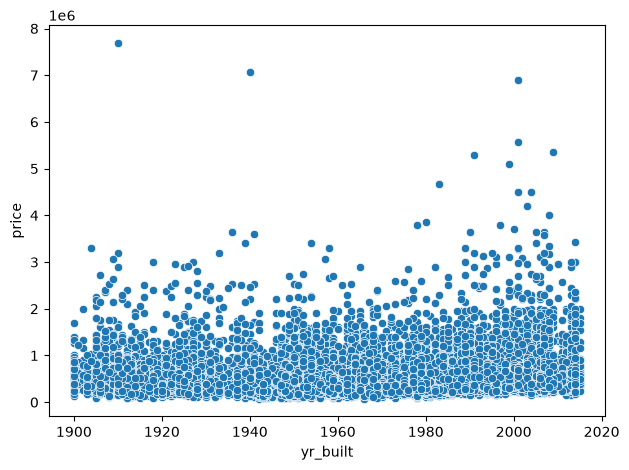

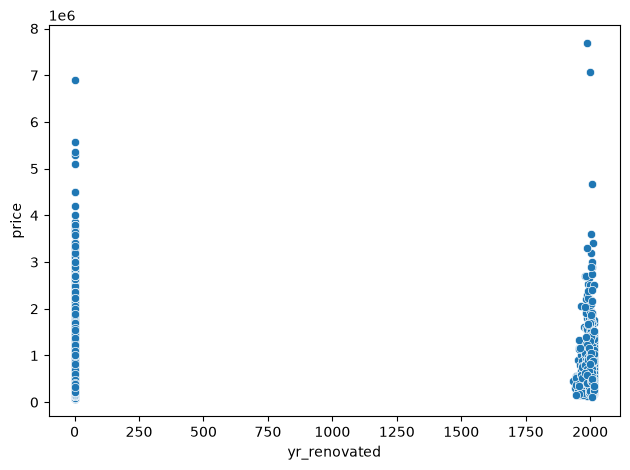

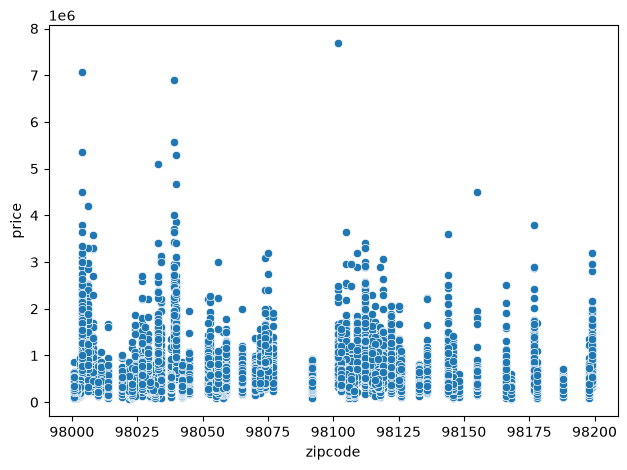

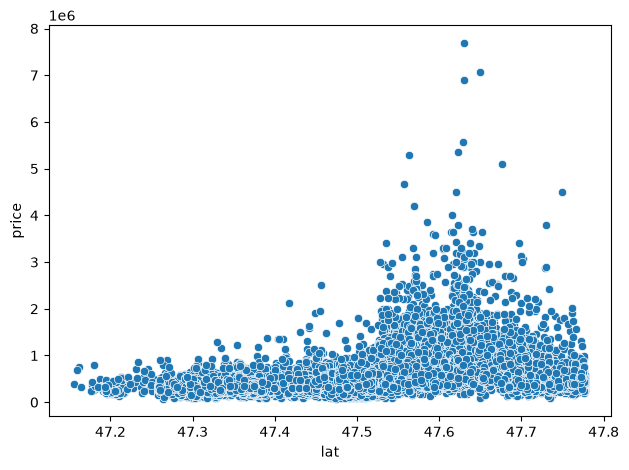

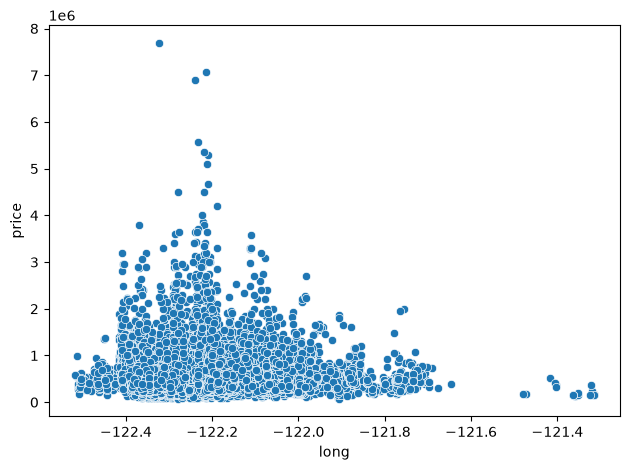

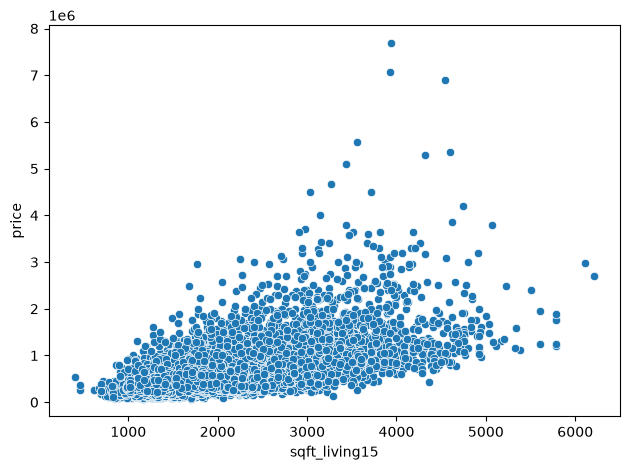

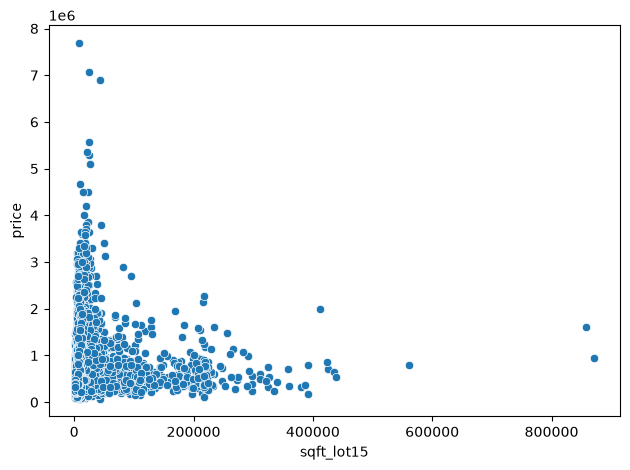

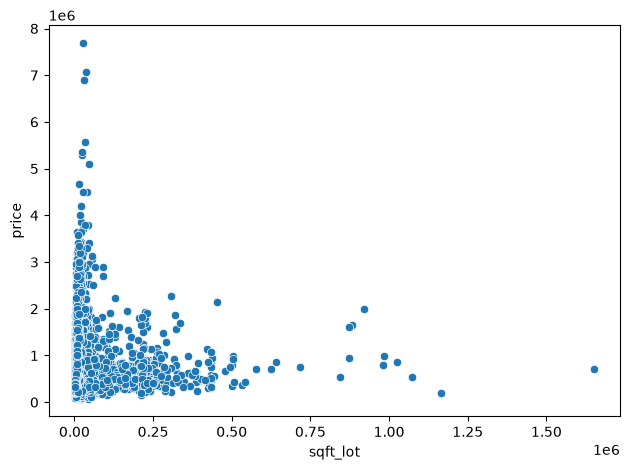

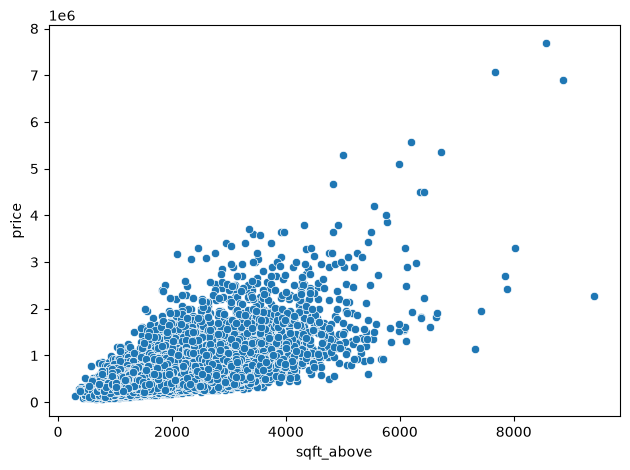

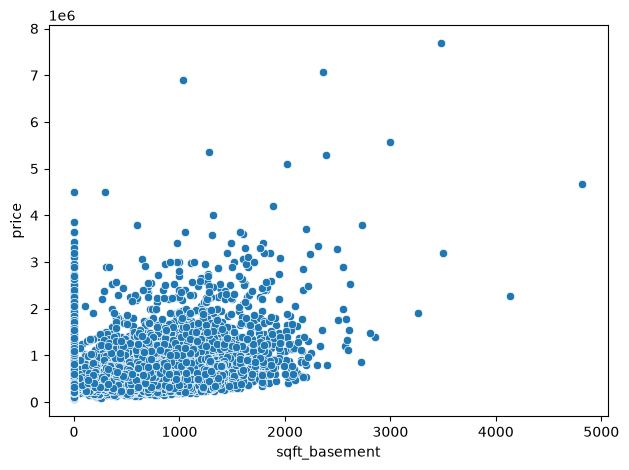

In [15]:
for col in df.drop(columns="price").columns:
    sns.scatterplot(data=df, x=df[col], y=df["price"])
    plt.tight_layout()
    plt.show()


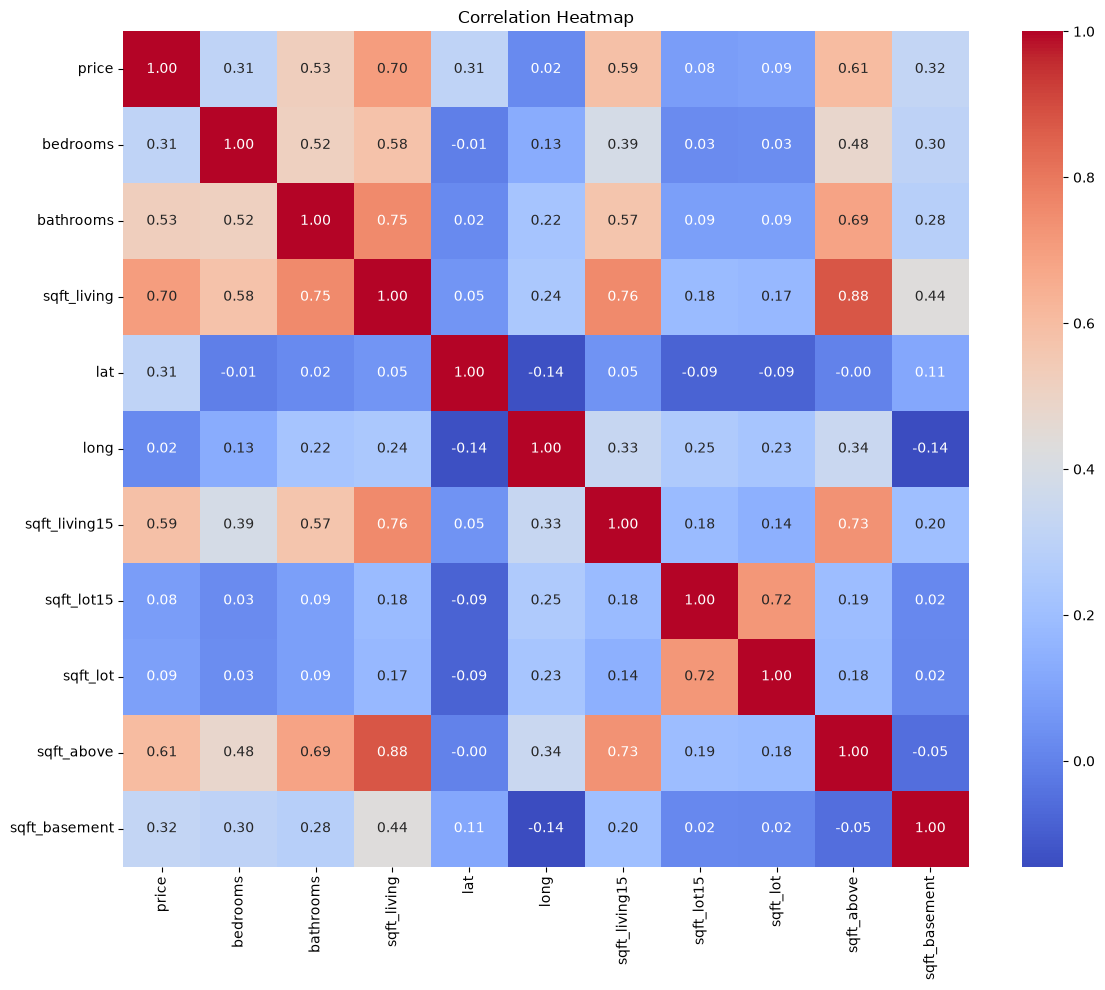

In [16]:
df_filtered = df.drop(columns=catcol + ['date'], errors='ignore')

plt.figure(figsize=(12, 10))
sns.heatmap(
    df_filtered.corr(numeric_only=True),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


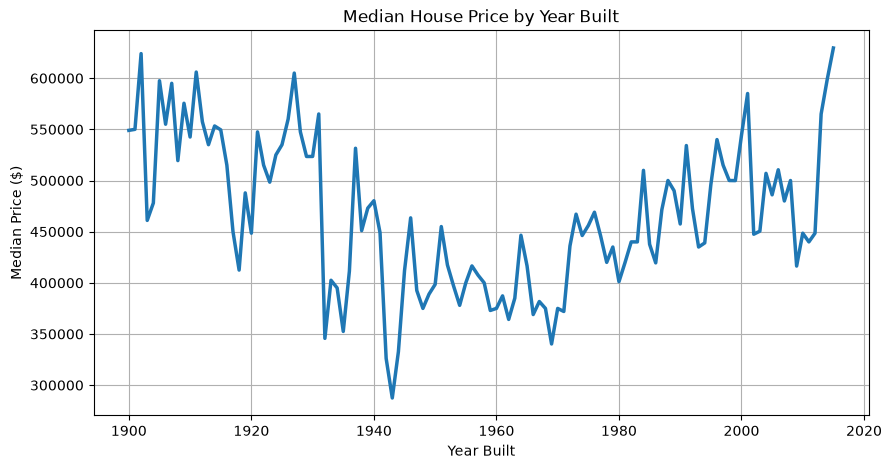

In [17]:
df.groupby('yr_built')['price'].median().plot(figsize=(10, 5), linewidth=2.5)
plt.title("Median House Price by Year Built")
plt.ylabel("Median Price ($)")
plt.xlabel("Year Built")
plt.grid(True)
plt.show()


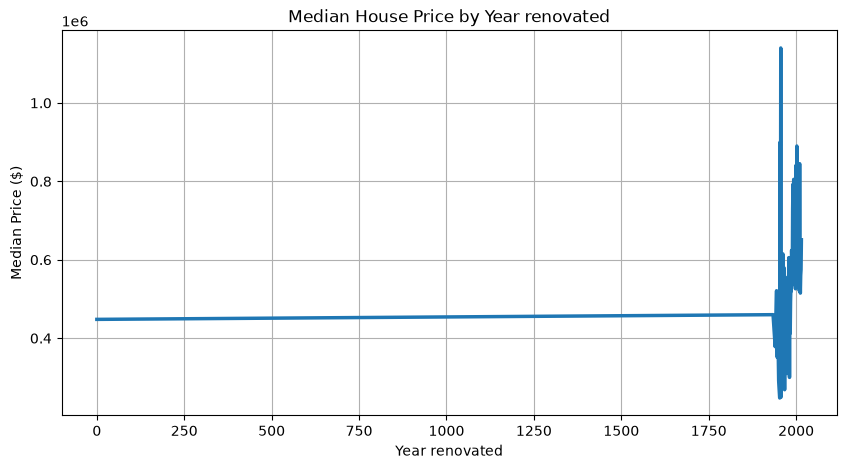

In [18]:
df.groupby('yr_renovated')['price'].median().plot(figsize=(10, 5), linewidth=2.5)
plt.title("Median House Price by Year renovated")
plt.ylabel("Median Price ($)")
plt.xlabel("Year renovated")
plt.grid(True)
plt.show()


## 3. Outlier Analysis

In [19]:
def get_iqr_outliers_count(dataframe):
    numeric_cols = dataframe.select_dtypes(include=['int64', 'float64']).columns
    outlier_counts = {}
    for col in numeric_cols:
        Q1 = dataframe[col].quantile(0.25)
        Q3 = dataframe[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        count = ((dataframe[col] < lower_bound) | (dataframe[col] > upper_bound)).sum()
        outlier_counts[col] = count
    return pd.Series(outlier_counts, name="Outlier_Count")


In [20]:
get_iqr_outliers_count(df[numcol])


price            1159
bedrooms          546
bathrooms         571
sqft_living       572
sqft_lot         2425
sqft_above        611
sqft_basement     496
sqft_living15     544
sqft_lot15       2194
lat                 2
long              256
Name: Outlier_Count, dtype: int64

## 4. Feature Engineering

In [21]:
df['home_age'] = 2016 - df['yr_built']
df['is_renovated'] = (df['yr_renovated'] > 0).astype(int)
df['years_since_renovation'] = df.apply(
    lambda r: 2016 - r['yr_renovated'] if r['yr_renovated'] > 0 else 0, axis=1
)


In [22]:
bins = [1899, 1935, 1960, 1980, 2000, 2016]
labels = ['Pre_WWII', 'MidCentury', 'Late20th', 'TurnOfCentury', 'Modern']
df['built_era'] = pd.cut(df['yr_built'], bins=bins, labels=labels)
df = df.drop(columns=['yr_built'])


In [23]:
bins = [-1, 0, 1980, 2000, 2016]
labels = ['non_renovated', 'renovated_pre_1980', 'renovated_1980s_90s', 'renovated_2000s_plus']
df['renovated_era'] = pd.cut(df['yr_renovated'], bins=bins, labels=labels)
df = df.drop(columns=['yr_renovated'])


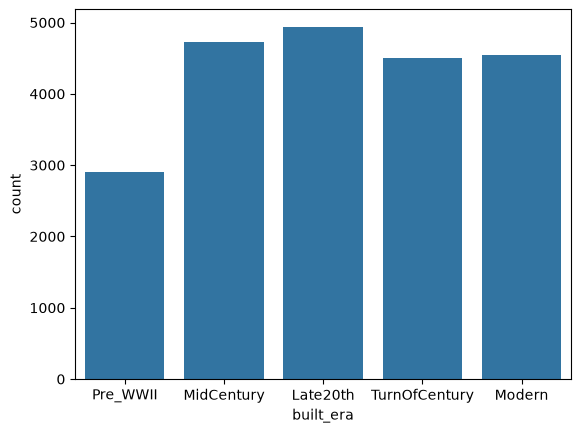

In [24]:
sns.countplot(x=df['built_era'])
plt.show()


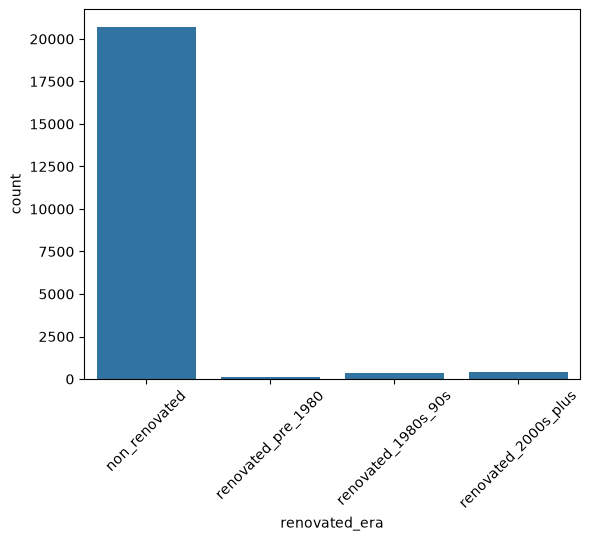

In [25]:
sns.countplot(x=df['renovated_era'])
plt.xticks(rotation=45)
plt.show()


In [26]:
# Coordinates for Downtown Seattle
SEATTLE_LAT, SEATTLE_LONG = 47.6062, -122.3321
BELLEVUE_LAT, BELLEVUE_LONG = 47.6101, -122.2015
# Euclidean distance feature
df['dist_to_seattle'] = np.sqrt(
    (df['lat'] - SEATTLE_LAT)**2 + (df['long'] - SEATTLE_LONG)**2
)

df['dist_to_bellevue'] = np.sqrt(
    (df['lat'] - BELLEVUE_LAT)**2 + (df['long'] - BELLEVUE_LONG)**2
)
df['dist_to_nearest_hub'] = np.minimum(df['dist_to_seattle'], df['dist_to_bellevue'])

print("Nearest Hub Correlation:", df['dist_to_nearest_hub'].corr(df['price']))


Nearest Hub Correlation: -0.329906335674479


In [27]:
df = df.drop(columns=['dist_to_seattle', 'dist_to_bellevue', 'lat', 'long', 'sqft_lot', 'date', 'sqft_above', 'sqft_lot15'])


## 5. Data Preparation

In [28]:
df = df[(df['bedrooms'] > 0) & (df['bedrooms'] < 10)]


In [29]:
x=df.drop(columns="price")
y=df["price"]


In [30]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = .2,random_state = 42,shuffle = True)


## 6. Advanced Features

In [31]:
def build_zip_target_map(x_train_raw, y_train_raw):
    """Mean log(price) per zipcode, computed on TRAIN ONLY to avoid leakage."""
    tmp = pd.DataFrame({'zipcode': x_train_raw['zipcode'].values,
                         'log_price': np.log1p(y_train_raw.values)})
    zip_map = tmp.groupby('zipcode')['log_price'].mean()
    global_mean = tmp['log_price'].mean()
    return zip_map, global_mean


def build_zip_aggregates(x_train_raw):
    """Per-zipcode aggregates from training data only."""
    agg = {}
    agg['zip_median_sqft'] = x_train_raw.groupby('zipcode')['sqft_living'].median()
    agg['zip_avg_bed'] = x_train_raw.groupby('zipcode')['bedrooms'].mean()
    agg['zip_avg_bath'] = x_train_raw.groupby('zipcode')['bathrooms'].mean()
    agg['zip_wfr_ratio'] = x_train_raw.groupby('zipcode')['waterfront'].mean()
    agg['zip_avg_condition'] = x_train_raw.groupby('zipcode')['condition'].mean()
    agg['zip_avg_grade'] = x_train_raw.groupby('zipcode')['grade'].mean()
    agg['defaults'] = {
        'zip_median_sqft': x_train_raw['sqft_living'].median(),
        'zip_avg_bed': x_train_raw['bedrooms'].mean(),
        'zip_avg_bath': x_train_raw['bathrooms'].mean(),
        'zip_wfr_ratio': 0,
        'zip_avg_condition': x_train_raw['condition'].mean(),
        'zip_avg_grade': x_train_raw['grade'].mean(),
    }
    return agg


def dataedite(df_input, zip_map=None, global_mean=None, zip_agg=None):
    df_processed = df_input.copy()

    df_processed['has_basement'] = (df_processed['sqft_basement'] > 0).astype(int)
    df_processed['log_sqft_basement'] = np.log1p(df_processed['sqft_basement'])
    df_processed = df_processed.drop(columns=['sqft_basement'])
    df_processed['log_sqft_living15'] = np.log1p(df_processed['sqft_living15'])
    df_processed['log_sqft_living'] = np.log1p(df_processed['sqft_living'])
    df_processed['log_dist_nearest_hub'] = np.log1p(df_processed['dist_to_nearest_hub'])
    df_processed = df_processed.drop(columns=['dist_to_nearest_hub'])

    if zip_map is not None:
        df_processed['zip_price_index'] = df_processed['zipcode'].map(zip_map).fillna(global_mean)

    if zip_agg is not None:
        for key in ['zip_median_sqft','zip_avg_bed','zip_avg_bath',
                     'zip_wfr_ratio','zip_avg_condition','zip_avg_grade']:
            df_processed[key] = df_processed['zipcode'].map(zip_agg[key]).fillna(zip_agg['defaults'][key])

    df_processed = df_processed.drop(columns=['zipcode'])

    df_processed['grade_x_sqft_living'] = df_processed['grade'] * df_processed['log_sqft_living']
    df_processed['grade_x_condition'] = df_processed['grade'] * df_processed['condition']
    df_processed['bath_x_sqft_living'] = df_processed['bathrooms'] * df_processed['log_sqft_living']
    df_processed['bed_bath_ratio'] = df_processed['bedrooms'] / (df_processed['bathrooms'] + 0.5)
    df_processed['view_x_waterfront'] = df_processed['view'] * df_processed['waterfront']
    df_processed['floors_x_sqft'] = df_processed['floors'] * df_processed['log_sqft_living']
    df_processed['condition_x_view'] = df_processed['condition'] * df_processed['view']
    df_processed['sqft_per_bedroom'] = df_processed['log_sqft_living'] / (df_processed['bedrooms'] + 1)
    df_processed['sqft_per_bathroom'] = df_processed['log_sqft_living'] / (df_processed['bathrooms'] + 1)
    df_processed['home_age_sq'] = df_processed['home_age'] ** 2
    df_processed['is_renovated_x_age'] = df_processed['is_renovated'] * df_processed['home_age']

    if 'built_era' in df_processed.columns:
        df_processed = pd.get_dummies(df_processed, columns=['built_era'], drop_first=True)

    if 'renovated_era' in df_processed.columns:
        df_processed = pd.get_dummies(df_processed, columns=['renovated_era'], drop_first=True)

    bool_cols = df_processed.select_dtypes(include=['bool']).columns
    df_processed[bool_cols] = df_processed[bool_cols].astype(int)
    raw_to_drop = ['sqft_living15']
    df_processed = df_processed.drop(columns=[col for col in raw_to_drop if col in df_processed.columns])
    return df_processed


In [32]:
zip_map, global_mean = build_zip_target_map(x_train, y_train)
zip_agg = build_zip_aggregates(x_train)
x_train = dataedite(x_train, zip_map=zip_map, global_mean=global_mean, zip_agg=zip_agg)
x_test = dataedite(x_test, zip_map=zip_map, global_mean=global_mean, zip_agg=zip_agg)


## 7. Model Training & Evaluation

In [33]:
y_train_log = np.log1p(y_train)

model = LinearRegression()
model.fit(x_train, y_train_log)

y_train_pred_log = model.predict(x_train)
y_test_pred_log = model.predict(x_test)

y_train_pred = np.expm1(y_train_pred_log)
y_test_pred = np.expm1(y_test_pred_log)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(f"Train R2: {train_r2:.4f}")
print(f"Test R2:  {test_r2:.4f}")


Train R2: 0.8819
Test R2:  0.9002


In [34]:
train_MSE = mean_squared_error(y_train, y_train_pred)
test_MSE = mean_squared_error(y_test, y_test_pred)
print(f"Train MSE: {train_MSE:.4f}")
print(f"Test MSE:  {test_MSE:.4f}")


Train MSE: 15801745835.4001
Test MSE:  13938958703.5977


In [35]:
from sklearn.metrics import mean_absolute_error
mae_test = mean_absolute_error(y_test, y_test_pred)
mape_test = np.mean(np.abs((y_test - y_test_pred) / y_test)) * 100
print(f"Test MAE:  ${mae_test:,.0f}")
print(f"Test MAPE: {mape_test:.2f}%")

Test MAE:  $71,727
Test MAPE: 13.37%
